Scaling and Transformations

In [19]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
import matplotlib as mpl
import matplotlib.pyplot as plt

Scaling and trasnformation data
scaling adjusts data to common scale,like converting measurements to the same units...this prevents one feature from dominating others in analysis or machine learning..exploring techniques like Z-score normalization and  min-max scaling

In [20]:
pokemon = pd.read_csv("/Users/mohammedsadmanuddin/data analysis/Scaling and Transformations/Pokemon (2).csv",sep=";")
pokemon.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


In [21]:
mean=pokemon["Total"].mean()
mean

np.float64(435.1025)

In [22]:
median=pokemon["Total"].median()
median

450.0

In [23]:
std=pokemon["Total"].std()
std

119.963039755519

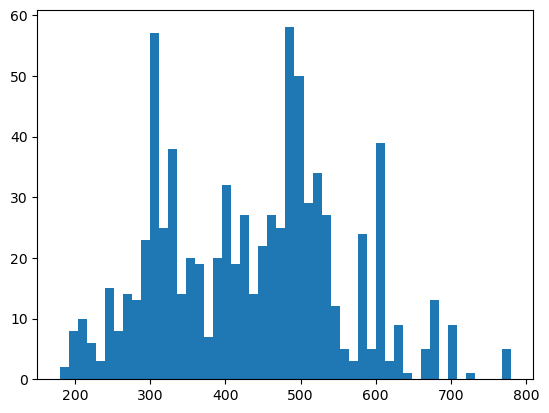

In [25]:
plt.hist(pokemon["Total"],bins=50)
plt.show()

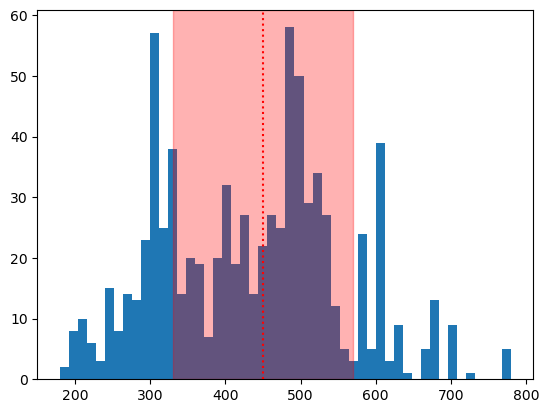

In [27]:
plt.hist(pokemon["Total"],bins=50)
plt.axvline(median,zorder=1,color="r",linestyle="dotted")
plt.axvspan(median-std,median+std,zorder=1,color="r",alpha=0.3)
plt.show()

### centralization
centering data is like moving a group of numbers so their avg is at zero...like sbtracting the mean from each value...this removes all ofset and helps algorithms work better.

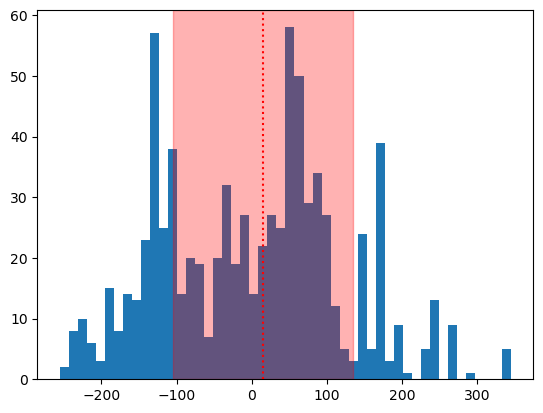

In [30]:
##to center the data,calculate the mean and subtract it from every value.
total_center = pokemon['Total']-mean
TC_median = total_center.median()
TC_std = total_center.std()

plt.hist(total_center,bins=50)
plt.axvline(TC_median,zorder=1,color="r",linestyle="dotted")
plt.axvspan(TC_median-TC_std,TC_median+TC_std,zorder=1,color="r",alpha=0.3)

In [31]:
#write a function that takes a single column as input and outputs a centralised column instead
def EnhanceData(data):
    data_center=data.mean()
    data_centralised = data-data_center
    return data_centralised

###Normalization
normalization standardizes data to a common scale...two main methods are Z-score and Min-Max
Z-score normalization centers the data at zero and scales it so the standard deviation is 1...this makes data comparable

it centers first..then devides by the std

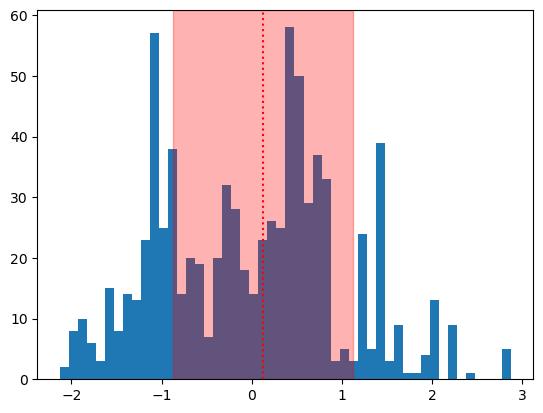

In [33]:
total_zscore=total_center/TC_std
total_zscore_median=total_zscore.median()
total_zscore_std=total_zscore.std()

plt.hist(total_zscore,bins=50)
plt.axvline(total_zscore_median,zorder=1,color="r",linestyle="dotted")
plt.axvspan(total_zscore_median-total_zscore_std,total_zscore_median+total_zscore_std,zorder=1,color="r",alpha=0.3)

In [37]:
data_to_scale = pokemon['Total'].values.reshape((len(pokemon["Total"]),1))
scaler=preprocessing.StandardScaler()
scaler=scaler.fit(data_to_scale)
normalized=scaler.transform(data_to_scale)
normalized[:10]

array([[-0.97676549],
       [-0.25108843],
       [ 0.74984544],
       [ 1.58395701],
       [-1.05183553],
       [-0.25108843],
       [ 0.82491548],
       [ 1.65902705],
       [ 1.65902705],
       [-1.01012996]])

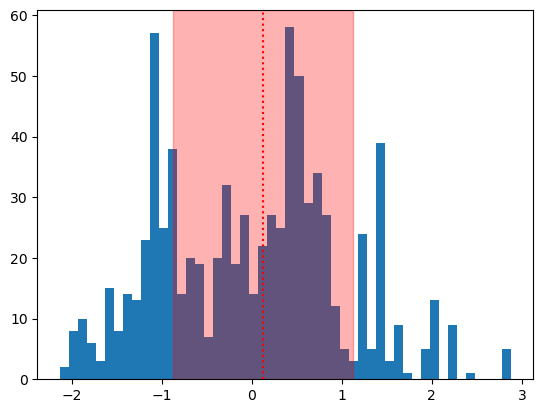

In [39]:
normalized_median = np.median(normalized)
normalized_std = normalized.std()

plt.hist(normalized,bins=50)
plt.axvline(normalized_median,zorder=1,color="r",linestyle="dotted")
plt.axvspan(normalized_median-normalized_std,normalized_median+normalized_std,zorder=1,color="r",alpha=0.3)
plt.show()

In [45]:
data_to_scale = pokemon['HP'].values.reshape((len(pokemon["Total"]),1))
scaler=preprocessing.MinMaxScaler()
scaler=scaler.fit(data_to_scale)
normalized=scaler.transform(data_to_scale)
normalized[:10]

array([[0.17322835],
       [0.23228346],
       [0.31102362],
       [0.31102362],
       [0.1496063 ],
       [0.22440945],
       [0.30314961],
       [0.30314961],
       [0.30314961],
       [0.16929134]])

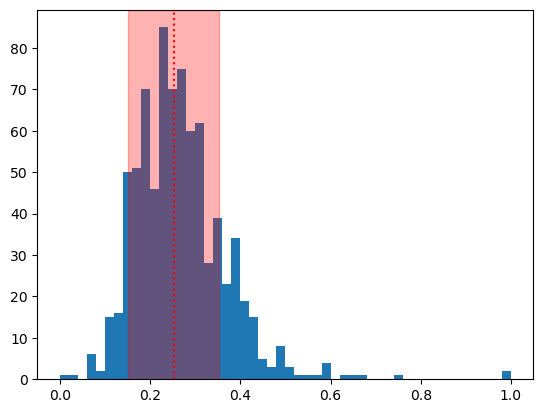

In [46]:
normalized_median = np.median(normalized)
normalized_std = normalized.std()

plt.hist(normalized,bins=50)
plt.axvline(normalized_median,zorder=1,color="r",linestyle="dotted")
plt.axvspan(normalized_median-normalized_std,normalized_median+normalized_std,zorder=1,color="r",alpha=0.3)
plt.show()

In [47]:
def EnhanceData(data,tech=""):
    data_center=data.mean()
    data_normalized=data-data_center
    if tech=="Z-score":
        data_to_scale = data.values.reshape((len(pokemon["Total"]),1))
        scaler=preprocessing.StandardScaler()
        scaler=scaler.fit(data_to_scale)
        normalized=scaler.transform(data_to_scale)
    elif tech=="MinMax":
        data_to_scale = data.values.reshape((len(pokemon["Total"]),1))
        scaler=preprocessing.MinMaxScaler()
        scaler=scaler.fit(data_to_scale)
        normalized=scaler.transform(data_to_scale)
    return data_normalized


(array([ 29.,  73., 154.,  97., 115., 198.,  49.,  52.,  27.,   6.]),
 array([-255.1025, -195.1025, -135.1025,  -75.1025,  -15.1025,   44.8975,
         104.8975,  164.8975,  224.8975,  284.8975,  344.8975]),
 <BarContainer object of 10 artists>)

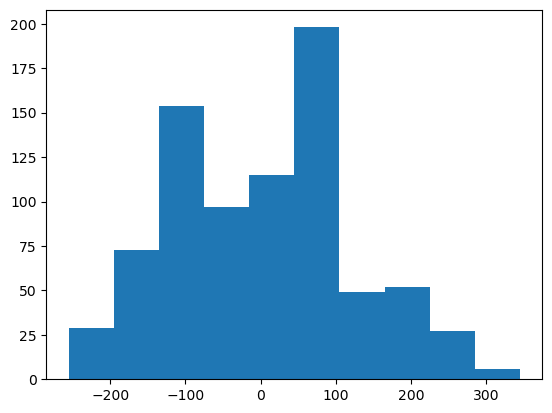

In [49]:
plt.hist(EnhanceData(pokemon['Total']))

(array([ 29.,  73., 154.,  97., 115., 198.,  49.,  52.,  27.,   6.]),
 array([-255.1025, -195.1025, -135.1025,  -75.1025,  -15.1025,   44.8975,
         104.8975,  164.8975,  224.8975,  284.8975,  344.8975]),
 <BarContainer object of 10 artists>)

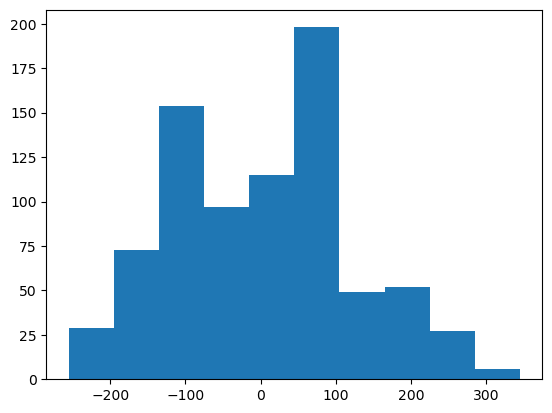

In [50]:
plt.hist(EnhanceData(pokemon['Total'],"MinMax"))

(array([ 10., 202., 336., 186.,  50.,  10.,   3.,   1.,   0.,   2.]),
 array([-68.25875, -42.85875, -17.45875,   7.94125,  33.34125,  58.74125,
         84.14125, 109.54125, 134.94125, 160.34125, 185.74125]),
 <BarContainer object of 10 artists>)

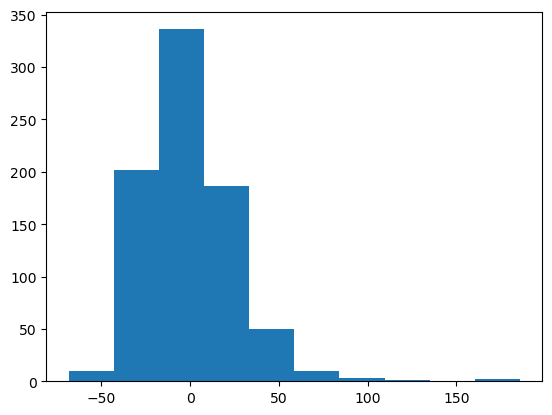

In [51]:
plt.hist(EnhanceData(pokemon['HP'],"z_score"))

. Z-score normalization (standardization)

Based on the idea of how far a value is from the mean.
	•	μ (mean) = average
	•	σ (standard deviation) = spread of data

What it does:
	•	Centers data around 0
	•	Scales it so standard deviation = 1
	•	Values typically fall between -3 and +3 (not fixed though)

When it works best:
	•	Data is roughly normally distributed
	•	You care about outliers (it keeps them visible)
	•	Algorithms like:
	•	Logistic regression
	•	SVM
	•	Neural networks

Problem:
	•	Sensitive to outliers → extreme values stretch the scale


Min-Max scaling (normalization)

Based on rescaling to a fixed range.

x’ = \frac{x - x_{min}}{x_{max} - x_{min}}

What it does:
	•	Transforms data into a fixed range (usually 0 to 1)
	•	Keeps the original shape of the distribution

When it works best:
	•	You need bounded values (e.g. pixels, probabilities)
	•	Algorithms like:
	•	KNN
	•	K-means
	•	Neural networks (especially with sigmoid)

Problem:
	•	Very sensitive to outliers
	•	One extreme value → everything else gets squished


###Transformations
log transformation helps when data spans a wide range,making large and small values comparable...for example income vary greatly with a few very high ones...taking the log compresses the range..reaveling patterns

In [ ]:
##usually apply log base 10